# Compare Countries Notebook


# Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# Load Cleaned Data Files


In [3]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Add Country Column


In [4]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
tanzania["Country"] = "Tanzania"
sudan["Country"] = "Sudan"
nigeria["Country"] = "Nigeria"

# Combine All Countries


In [ ]:
df = pd.concat([
    ethiopia,
    kenya,
    tanzania,
    sudan,
    nigeria
])

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


# Convert Date Column


In [6]:
df["DATE"] = pd.to_datetime(df["DATE"])

# Create YearMonth Column


In [7]:
df["YearMonth"] = df["DATE"].dt.to_period("M")

# Monthly Temperature Comparison


In [8]:
monthly_temp = df.groupby(
    ["YearMonth", "Country"]
)["T2M"].mean().reset_index()

monthly_temp["YearMonth"] = monthly_temp["YearMonth"].astype(str)

# Temperature Trend Plot


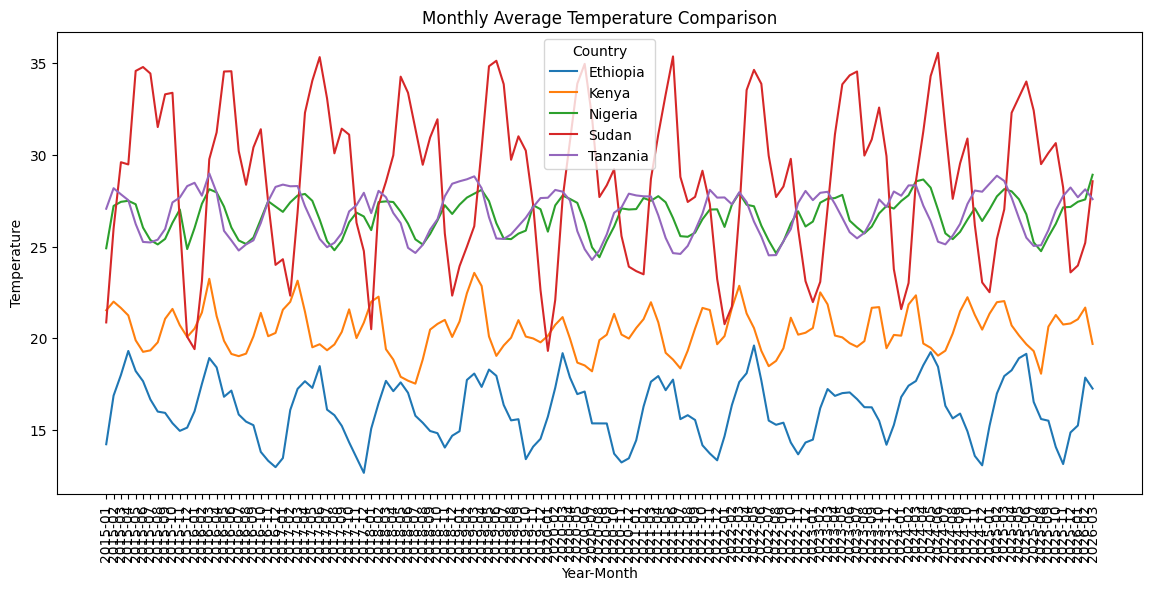

In [9]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_temp,
    x="YearMonth",
    y="T2M",
    hue="Country"
)

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature Comparison")
plt.xlabel("Year-Month")
plt.ylabel("Temperature")
plt.show()

# Temperature Summary Table


In [10]:
temp_summary = df.groupby("Country")["T2M"].agg([
    "mean",
    "median",
    "std"
])

temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


# Rainfall Boxplot


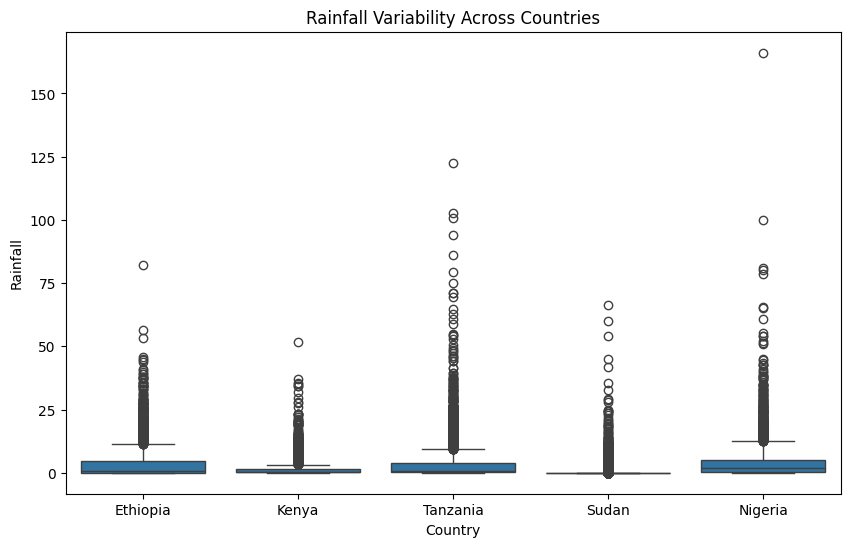

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Rainfall Variability Across Countries")
plt.xlabel("Country")
plt.ylabel("Rainfall")
plt.show()

# Rainfall Summary Table


In [12]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg([
    "mean",
    "median",
    "std"
])

rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


# Extreme Heat Days


In [13]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby("Country").size()

heat_counts

Country
Sudan    2694
dtype: int64

# Extreme Heat Plot


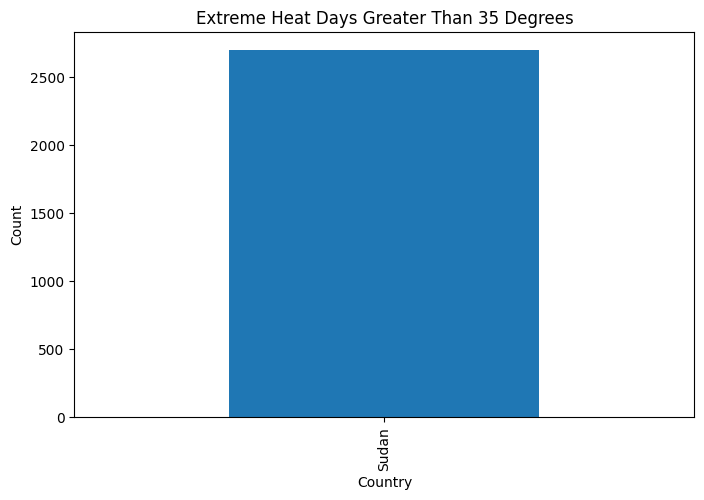

In [14]:
heat_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Extreme Heat Days Greater Than 35 Degrees")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# Dry Days


In [15]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_counts = dry_days.groupby("Country").size()

dry_counts

Country
Ethiopia    2161
Kenya       2831
Nigeria     1595
Sudan       3696
Tanzania    2303
dtype: int64

# Dry Days Plot


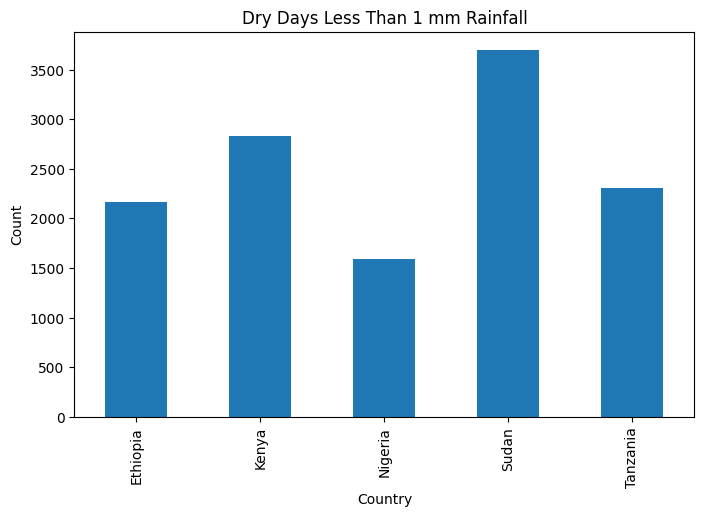

In [16]:
dry_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Dry Days Less Than 1 mm Rainfall")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# ANOVA Test


In [17]:
from scipy.stats import f_oneway

anova = f_oneway(
    ethiopia["T2M"],
    kenya["T2M"],
    tanzania["T2M"],
    sudan["T2M"],
    nigeria["T2M"]
)

print(f"F-statistic: {anova.statistic:.15f}")
print(f"P-value: {anova.pvalue:.30f}")
print(anova)

F-statistic: 18938.745697069916787
P-value: 0.000000000000000000000000000000
F_onewayResult(statistic=np.float64(18938.745697069917), pvalue=np.float64(0.0))


# ANOVA Interpretation


ANOVA was used to test whether average temperatures differ across countries.
The p-value is far below the significance threshold of 0.05.
This confirms meaningful climate differences across regions.
Statistically significant temperature variation suggests that climate adaptation strategies should be country-specific rather than regionally uniform.


# Vulnerability Score Table


In [18]:
vulnerability = pd.DataFrame({
    "ExtremeHeat": heat_counts,
    "DryDays": dry_counts
}).fillna(0)

vulnerability

,ExtremeHeat,DryDays
Country,,
Ethiopia,0.0,2161
Kenya,0.0,2831
Nigeria,0.0,1595
Sudan,2694.0,3696
Tanzania,0.0,2303


# Rank Countries By Vulnerability


In [19]:
vulnerability["Score"] = (
    vulnerability["ExtremeHeat"] +
    vulnerability["DryDays"]
)

ranking = vulnerability.sort_values(
    "Score",
    ascending=False
)

ranking

,ExtremeHeat,DryDays,Score
Country,,,
Sudan,2694.0,3696,6390.0
Kenya,0.0,2831,2831.0
Tanzania,0.0,2303,2303.0
Ethiopia,0.0,2161,2161.0
Nigeria,0.0,1595,1595.0
